In [2]:
import pandas as pd
import rdkit
import deepchem


Skipped loading some Pytorch utilities, missing a dependency. No module named 'torch'
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading some PyTorch models, missing a dependency. No module named 'torch'
No module named 'torch'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'torch'
Skipped loading some Jax

This module requires PyTorch to be installed.


In [8]:
!pip install optuna xgboost scikit-learn rdkit-pypi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 16.6 MB/s  0:00:01 eta 0:00:01


In [ ]:
# ==========================================
# CELLULE 1 (MISE À JOUR) : GÉNÉRATION DES DONNÉES ALIGNÉES (TRAIN 70 / TEST 20 / VAL 10)
# ==========================================
import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, MACCSkeys
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("1️⃣ Chargement des données...")
df_elec = pd.read_csv('df_elec.csv')

# On trie et on ne garde qu'une ligne par SMILES (MAA Max)
df_final = df_elec.sort_values(['smiles', 'MAA_values']).drop_duplicates('smiles', keep='last').reset_index(drop=True)
y = df_final['MAA_values'].values

print("2️⃣ Génération des Morgan Fingerprints (2048)...")
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_morgan = np.array([mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.zeros(2048) for s in tqdm(df_final['smiles'])])

print("3️⃣ Génération des MACCS Keys (167)...")
X_maccs = np.array([MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.zeros(167) for s in tqdm(df_final['smiles'])])

print("4️⃣ Génération de la Matrice Augmentée (Morgan + Sites + CM5)...")
def parse_gcs(x):
    try: return ast.literal_eval(x) if isinstance(x, str) else x
    except: return []

gcs_expanded = pd.DataFrame(df_final['elec_GCS_3_cm5'].apply(parse_gcs).tolist()).fillna(0)
df_final['elec_names_encoded'] = df_final['elec_names'].astype('category').cat.codes

X_aug = np.hstack([X_morgan, df_final[['elec_sites', 'elec_names_encoded']].values, gcs_expanded.values])

print("5️⃣ Triple Split Universel (Train 70% / Test 20% / Val 10%)...")
# ÉTAPE A : On sépare 70% (Train) et 30% (Temporaire)
X_train_morgan, X_temp_morgan, \
X_train_maccs, X_temp_maccs, \
X_train_aug, X_temp_aug, \
y_train, y_temp = train_test_split(
    X_morgan, X_maccs, X_aug, y, test_size=0.30, random_state=42
)

# ÉTAPE B : On sépare les 30% restants (2/3 pour Test -> 20% du total, 1/3 pour Val -> 10% du total)
X_test_morgan, X_val_morgan, \
X_test_maccs, X_val_maccs, \
X_test_aug, X_val_aug, \
y_test, y_val = train_test_split(
    X_temp_morgan, X_temp_maccs, X_temp_aug, y_temp, test_size=(0.10/0.30), random_state=42
)

print("\n✅ Répartition finale :")
print(f"   • Train      : {len(y_train)} molécules ({len(y_train)/len(y)*100:.0f}%)")
print(f"   • Test       : {len(y_test)} molécules ({len(y_test)/len(y)*100:.0f}%)")
print(f"   • Validation : {len(y_val)} molécules ({len(y_val)/len(y)*100:.0f}%)")

1️⃣ Chargement des données...
2️⃣ Génération des Morgan Fingerprints (2048)...


100%|██████████| 47440/47440 [00:07<00:00, 6369.19it/s]


3️⃣ Génération des MACCS Keys (167)...


100%|██████████| 47440/47440 [00:23<00:00, 2048.15it/s]


4️⃣ Génération de la Matrice Augmentée (Morgan + Sites + CM5)...
5️⃣ Triple Split Universel (Train 70% / Test 20% / Val 10%)...

✅ Répartition finale :
   • Train      : 33208 molécules (70%)
   • Test       : 9487 molécules (20%)
   • Validation : 4745 molécules (10%)


In [ ]:
# ==========================================
# CELLULE 2 : DÉFINITION DE TOUS LES MODÈLES
# ==========================================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Les Basiques (Sur Morgan)
ranf_reg = RandomForestRegressor(
    n_estimators=1000, max_depth=10, min_samples_leaf=5, max_features='sqrt', 
    n_jobs=6, random_state=42
)

xgb_reg = XGBRegressor(
    n_estimators=1000, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, 
    n_jobs=6, random_state=42
)


# 2. Les Optimisés (Sur Morgan)
xgb_morgan_GridSearchCV = XGBRegressor(
    n_estimators=300, max_depth=7, learning_rate=0.1, 
    subsample=0.8, colsample_bytree=0.8, 
    n_jobs=6, random_state=42
)

xgb_morgan_OPTUNA = XGBRegressor(
    n_estimators=1800, max_depth=11, learning_rate=0.0617, 
    min_child_weight=10, subsample=0.840, colsample_bytree=0.723, 
    tree_method='hist', n_jobs=6, random_state=42
)


# 3. Les Modèles Augmentés (Sur Morgan + Charges)
xgb_aug = XGBRegressor(
    n_estimators=1000, max_depth=9, learning_rate=0.1, 
    subsample=0.8, colsample_bytree=0.8, 
    tree_method='hist', n_jobs=6, random_state=42
)

xgb_aug_OPTUNA = XGBRegressor(
    n_estimators=2400, max_depth=11, learning_rate=0.0385, 
    min_child_weight=10, reg_alpha=0.062, reg_lambda=9.69, 
    subsample=0.824, colsample_bytree=0.658, 
    tree_method='hist', n_jobs=6, random_state=42
)


# 4. Le Modèle Léger (Sur MACCS)
xgb_maccs = XGBRegressor(
    n_estimators=1000, max_depth=10, learning_rate=0.1, 
    tree_method='hist', n_jobs=6, random_state=42
)

xgb_maccs_OPTUNA = XGBRegressor(
    n_estimators=1600, max_depth=9, learning_rate=0.0209, 
    min_child_weight=3, reg_alpha=1.232, reg_lambda=0.0075, 
    subsample=0.611, colsample_bytree=0.650, 
    tree_method='hist', n_jobs=6, random_state=42


   

In [ ]:
# ==========================================
# CELLULE 3 : FONCTION D'ÉVALUATION UNIVERSELLE
# ==========================================
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.auto import tqdm

all_results = []

def train_test_model(model, X_train_matrix, y_train_vector, X_test_matrix, y_test_vector, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        # Entraînement
        model.fit(X_train_matrix, y_train_vector)
        pbar.update(1)
        
        # Prédiction
        y_pred_train = model.predict(X_train_matrix)
        y_pred_test = model.predict(X_test_matrix)
        pbar.update(1)
        
        # Calcul
        train_rmse = mean_squared_error(y_train_vector, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test_vector, y_pred_test) ** 0.5
        train_r2 = r2_score(y_train_vector, y_pred_train)
        test_r2 = r2_score(y_test_vector, y_pred_test)
        
        mean_val = np.mean(y_test_vector)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })
    return y_pred_test

In [24]:
# ==========================================
# CELLULE 4 : ENTRAÎNEMENT DE LA FLOTTE COMPLÈTE
# ==========================================
# On vide la liste pour éviter les doublons si on relance la cellule
all_results.clear()

print("🏁 Lancement des entraînements...")

# 1. Entraînements sur données Morgan (Classique)
preds_rf = train_test_model(ranf_reg, X_train_morgan, y_train, X_test_morgan, y_test, name="Morgan Random Forest")
preds_xgb = train_test_model(xgb_reg, X_train_morgan, y_train, X_test_morgan, y_test, name="Morgan XGBoost")
preds_xgb_GridSearchCV = train_test_model(xgb_morgan_GridSearchCV, X_train_morgan, y_train, X_test_morgan, y_test, name="Morgan XGBoost GridSearchCV")
preds_xgb_OPTUNA = train_test_model(xgb_morgan_OPTUNA, X_train_morgan, y_train, X_test_morgan, y_test, name="Morgan XGBoost OPTUNA")

# 2. Entraînements sur données Augmentées (Morgan + Charges)
preds_xgb_final = train_test_model(xgb_aug, X_train_aug, y_train, X_test_aug, y_test, name="Morgan XGBoost_Augmenté")
preds_xgb_OPTUNA_aug = train_test_model(xgb_aug_OPTUNA, X_train_aug, y_train, X_test_aug, y_test, name="Morgan XGBoost_Augmenté OPTUNA ")

# 3. Entraînement sur données MACCS (SMILES pur)
preds_maccs = train_test_model(xgb_maccs, X_train_maccs, y_train, X_test_maccs, y_test, name="MACCS XGBoost")
preds_maccs_OPTUNA = train_test_model(xgb_maccs_OPTUNA, X_train_maccs, y_train, X_test_maccs, y_test, name="MACCS XGBoost OPTUNA ")

🏁 Lancement des entraînements...


✨ MACCS XGBoost OPTUNA  Terminé: 100%|██████████| 3/3 [00:06<00:00,  2.12s/it]


📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
5,Morgan XGBoost_Augmenté OPTUNA,19.77,0.881,11.0%,4.41,0.994
4,Morgan XGBoost_Augmenté,21.19,0.864,11.8%,3.44,0.996
3,Morgan XGBoost OPTUNA,28.94,0.746,16.1%,9.28,0.973
1,Morgan XGBoost,29.24,0.740,16.2%,6.99,0.985
2,Morgan XGBoost GridSearchCV,30.92,0.709,17.2%,22.45,0.842
7,MACCS XGBoost OPTUNA,30.93,0.709,17.2%,12.05,0.955
6,MACCS XGBoost,31.75,0.694,17.6%,2.82,0.998
0,Morgan Random Forest,47.30,0.320,26.3%,45.88,0.342


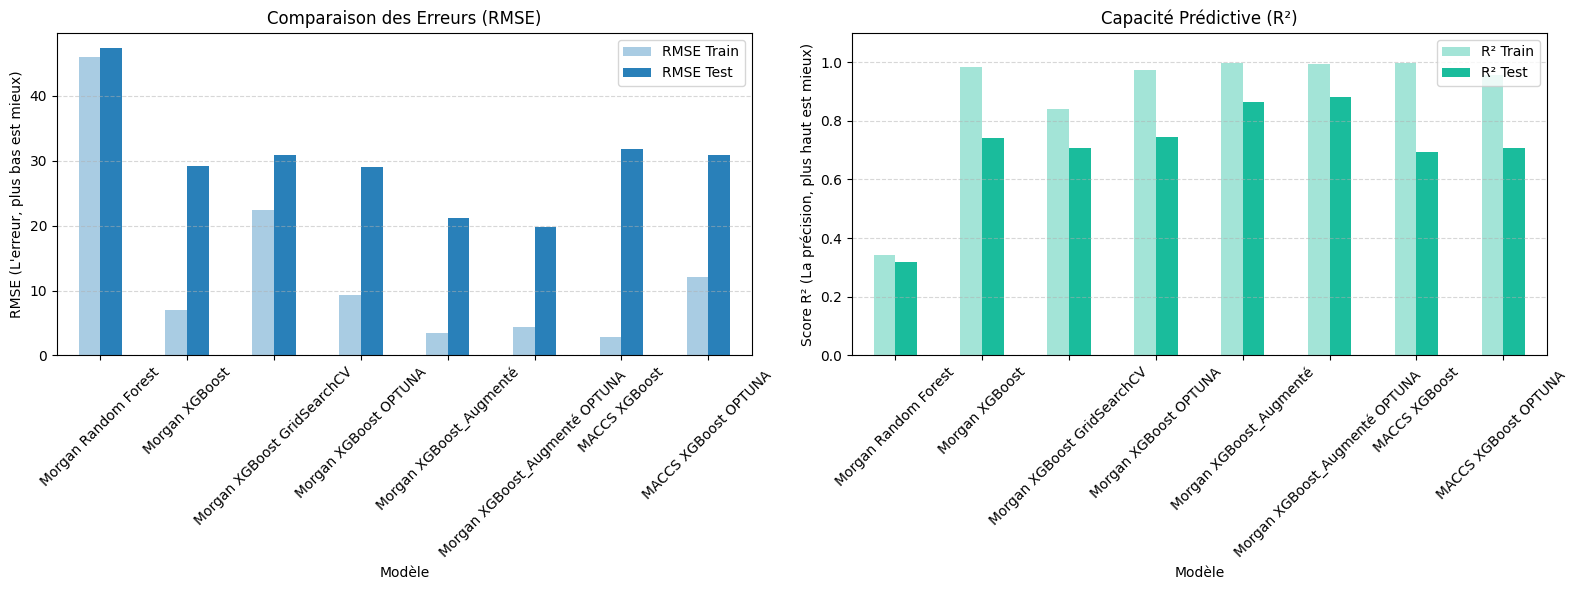

In [ ]:
# ==========================================
# CELLULE 5 : AFFICHAGE DU TABLEAU DE CHASSE
# ==========================================
import matplotlib.pyplot as plt

df_final_results = pd.DataFrame(all_results)

print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
display(df_final_results.sort_values(by='RMSE Test'))

# Graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1, color=['#A9CCE3', '#2980B9'])
ax1.set_ylabel("RMSE (L'erreur, plus bas est mieux)")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2, color=['#A3E4D7', '#1ABC9C'])
ax2.set_ylabel("Score R² (La précision, plus haut est mieux)")
ax2.set_ylim(0, 1.1) 
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
## Optimisation optuna sur ## 




In [ ]:
# ==========================================
# CELLULE OPTUNA : OPTIMISATION DU MODÈLE MACCS
# ==========================================
import optuna
from sklearn.model_selection import KFold, cross_val_score

print("🌙 Lancement d'Optuna sur les données MACCS (SMILES Pur)...")

# 1. DÉFINITION DE LA FONCTION OBJECTIVE
def objective_maccs(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'tree_method': 'hist',
        'n_jobs': 6, 
        'random_state': 42
    }

    model = XGBRegressor(**param)
    
    # Cross-validation (5-fold) sur le train set MACCS
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_maccs, y_train, cv=kf, scoring='r2', n_jobs=1)
    
    return scores.mean()

# 2. LANCEMENT DE LA RECHERCHE (30 essais)
study_maccs = optuna.create_study(direction='maximize', study_name="XGBoost_MACCS")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_maccs.optimize(objective_maccs, n_trials=30, show_progress_bar=True)

print(" Meilleurs paramètres MACCS trouvés :")
best_params_maccs = study_maccs.best_params
for key, value in best_params_maccs.items():
    print(f"    {key}: {value}")

# 3. ENTRAÎNEMENT DU MEILLEUR MODÈLE
best_params_maccs['tree_method'] = 'hist'
best_params_maccs['n_jobs'] = 6
best_params_maccs['random_state'] = 42

best_xgb_maccs = XGBRegressor(**best_params_maccs)

print("\n🚀 Évaluation du modèle Optuna MACCS sur le set de Test...")
# On utilise ta fonction train_test_model de la Cellule 3
preds_maccs_optuna = train_test_model(
    best_xgb_maccs, 
    X_train_maccs, y_train, 
    X_test_maccs, y_test, 
    name="XGBoost MACCS OPTUNA"
)

# 4. MISE À JOUR RAPIDE DES RÉSULTATS
df_final_results_updated = pd.DataFrame(all_results)
print("\n📊 NOUVEAU CLASSEMENT (Incluant MACCS Optuna) :")
display(df_final_results_updated.sort_values(by='RMSE Test'))

🌙 Lancement d'Optuna sur les données MACCS (SMILES Pur)...


Best trial: 13. Best value: 0.717324: 100%|██████████| 30/30 [10:15<00:00, 20.51s/it]



🏆 Meilleurs paramètres MACCS trouvés :
    n_estimators: 1600
    learning_rate: 0.020942821222183317
    max_depth: 9
    min_child_weight: 3
    subsample: 0.6107644577639075
    colsample_bytree: 0.6504744906699487
    reg_alpha: 1.2319036154757197
    reg_lambda: 0.007481365665962131

🚀 Évaluation du modèle Optuna MACCS sur le set de Test...


✨ XGBoost MACCS OPTUNA Terminé: 100%|██████████| 3/3 [00:07<00:00,  2.48s/it]


📊 NOUVEAU CLASSEMENT (Incluant MACCS Optuna) :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
5,XGBoost OPTUNA Augmenté,19.55,0.883,10.9%,4.66,0.993
4,XGBoost Augmenté,20.59,0.870,11.5%,7.05,0.985
3,XGBoost OPTUNA,28.44,0.753,15.8%,10.86,0.963
7,XGBoost MACCS OPTUNA,30.09,0.723,16.7%,12.77,0.949
6,XGBoost MACCS (SMILES pur),30.52,0.715,17.0%,18.83,0.890
2,XGBoost GridSearchCV,30.70,0.712,17.1%,22.93,0.837
1,XGBoost,33.69,0.653,18.7%,30.53,0.710
0,Random Forest,47.28,0.317,26.3%,46.14,0.338


In [ ]:
# ============================================================
# BLOC 1 : OPTUNA - MORGAN "PAS AUGMENTÉ" (SMILES UNIQUEMENT)
# ============================================================
import optuna

print("🌙 Lancement d'Optuna sur Morgan (SMILES pur)...")

def objective_morgan(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'n_jobs': 6,
        'random_state': 42
    }
    model = XGBRegressor(**param)
    model.fit(X_train_morgan, y_train)
    preds_val = model.predict(X_val_morgan)
    return r2_score(y_val, preds_val)

study_morgan = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Timeout de 45 minutes (2700 secondes)
study_morgan.optimize(objective_morgan, n_trials=30, timeout=2700, show_progress_bar=True)

print("\n🏆 Meilleurs paramètres Morgan (Pas Augmenté) :", study_morgan.best_params)

# Entraînement Final et Test
best_xgb_morgan = XGBRegressor(**study_morgan.best_params, tree_method='hist', n_jobs=6, random_state=42)
preds_morgan_optuna = train_test_model(
    best_xgb_morgan, X_train_morgan, y_train, X_test_morgan, y_test, 
    name="XGBoost Morgan OPTUNA (SMILES pur)"
)


🌙 Lancement d'Optuna sur Morgan (SMILES pur)...


Best trial: 13. Best value: 0.757998: 100%|██████████| 30/30 [11:50<00:00, 23.69s/it, 710.81/2700 seconds]



🏆 Meilleurs paramètres Morgan (Pas Augmenté) : {'n_estimators': 1800, 'learning_rate': 0.06173446898387508, 'max_depth': 11, 'min_child_weight': 10, 'subsample': 0.839655883285022, 'colsample_bytree': 0.7230875841227591}


✨ XGBoost Morgan OPTUNA (SMILES pur) Terminé: 100%|██████████| 3/3 [00:30<00:00, 10.23s/it]
